# Lab 4 Report:
## Surpass Human Performance in Fashion MNIST Classificaion

### Name:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [3]:
# Image('lab4_exercise.png', width = 1000)

## Prepare Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

base_path = '/content/drive/MyDrive/Colab Notebooks/Lab4_Template/Lab4_Template/Lab4_Template/'

train_features = np.load(base_path + 'fashion_mnist_train_features.npy')
train_targets = np.load(base_path + 'fashion_mnist_train_targets.npy')

test_features = np.load(base_path + 'fashion_mnist_test_features.npy')
test_targets = np.load(base_path + 'fashion_mnist_test_targets.npy')

# Let's see the shapes of training/testing datasets
print("Training Features Shape: ", train_features.shape)
print("Training Targets Shape: ", train_targets.shape)
print("Testing Features Shape: ", test_features.shape)
print("Testing Targets Shape: ", test_targets.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training Features Shape:  (10000, 28, 28)
Training Targets Shape:  (10000,)
Testing Features Shape:  (1000, 28, 28)
Testing Targets Shape:  (1000,)


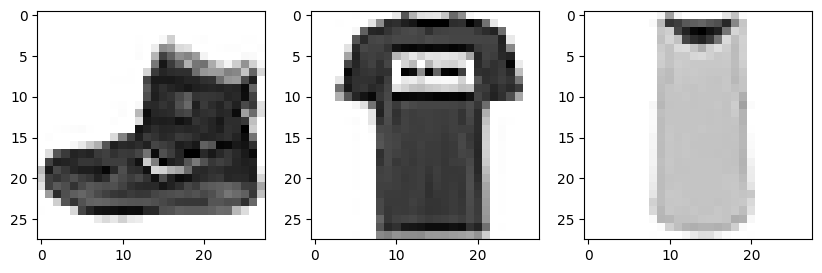

In [5]:
# Visualizing the first three training features (samples)

plt.figure(figsize = (10, 10))

plt.subplot(1,3,1)
plt.imshow(train_features[0], cmap = 'Greys')

plt.subplot(1,3,2)
plt.imshow(train_features[1], cmap = 'Greys')

plt.subplot(1,3,3)
plt.imshow(train_features[2], cmap = 'Greys')

In [6]:
# Reshape features via flattening the images
# This refers to reshape each sample from a 2d array to a 1d array.

# Convert both images to a vector of length 784 using np.reshape
train_features = train_features.reshape(train_features.shape[0], -1)
test_features = test_features.reshape(test_features.shape[0], -1)

In [7]:
# Define a scaling function to normalize dataset

def scale_data(arr, mean=None, std=None):

    # If mean is not provided, compute mean for each feature (column-wise)
    if mean is None:
        mean = np.mean(arr, axis=0)

    # If std is not provided, compute standard deviation for each feature
    if std is None:
        std = np.std(arr, axis=0)

    # Avoid division by zero:
    std[std == 0] = 1  # avoid divide by zero

    # Return standardized scaled
    return (arr - mean) / std, mean, std

# Scale the training dataset
# This computes mean and std from training data only
train_features, mean, std = scale_data(train_features)

# Scale the test dataset using the same mean and std from training data
# This prevents data leakage, and makes sure of consistent scaling
test_features, _, _ = scale_data(test_features, mean, std)

In [8]:
# Take the first 1000 (or randomly select 1000) training features and targets as validation set
validation_features = train_features[:1000]
validation_targets = train_targets[:1000]

# Take the remaining 9000 training features and targets as training set
train_features = train_features[1000:]
train_targets = train_targets[1000:]

In [9]:
# Reshape train/validation/test sets to conform to PyTorch's (N, Channels, Height, Width) standard for CNNs

# Convert training data from (N, 784) or (N, 28, 28) to (N, 1, 28, 28)
train_features = train_features.reshape(train_features.shape[0], 1, 28, 28)

# Apply the same reshaping to validation data
validation_features = validation_features.reshape(validation_features.shape[0], 1, 28, 28)

# Apply the same reshaping to test data
test_features = test_features.reshape(test_features.shape[0], 1, 28, 28)

## Define Model

In [10]:
# Define your CNN architecture here

class CNNModel(torch.nn.Module):

    def __init__(self):
        super(CNNModel, self).__init__()

        # First convolution block: 1 input channel to 32 feature maps
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolution block: 32 feature maps to 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers for classification
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        # Dropout helps reduce overfitting
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Apply first convolution, activation, and pooling
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        # Apply second convolution, activation, and pooling
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        # Flatten feature maps before fully connected layers
        x = torch.flatten(x, 1)

        # Apply dense layer and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Output raw class scores for 10 classes
        out = self.fc2(x)

        return out

## Select Hyperparameters

In [11]:
# Fix the random seed so that model performance is reproducible
torch.manual_seed(55)

# Initialize your CNN model

model = CNNModel()

# Define learning rate, epoch and batchsize for mini-batch gradient

learning_rate = 0.001
epochs = 10
batchsize = 64


# Define loss function for multi-class classification
loss_func = nn.CrossEntropyLoss()

# Define optimizer (Adam)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

model

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

## Identify Tracked Values

In [12]:
# Placeholders for training loss and validation accuracy during training
# Training loss should be tracked for each iteration (1 iteration -> single forward pass to the network)
# Validation accuracy should be evaluated every 'Epoch' (1 epoch -> full training dataset)
# If using batch gradient, 1 iteration = 1 epoch


# Stores training loss at each iteration (each batch update)
train_loss_list = []

# Stores validation accuracy after each epoch (full pass through dataset)
validation_accuracy_list = []

## Train Model

In [13]:
import tqdm # Use "for epoch in tqdm.trange(epochs):" to see the progress bar

# Convert the training, validation, testing dataset (NumPy arrays) into torch tensors
# Split your training features/targets into mini-batches if using mini-batch gradient

# Convert numpy arrays into PyTorch tensors
train_features_tensor = torch.tensor(train_features, dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets, dtype=torch.long)

validation_features_tensor = torch.tensor(validation_features, dtype=torch.float32)
validation_targets_tensor = torch.tensor(validation_targets, dtype=torch.long)

test_features_tensor = torch.tensor(test_features, dtype=torch.float32)
test_targets_tensor = torch.tensor(test_targets, dtype=torch.long)

# Training Loop ---------------------------------------------------------------
for epoch in range(epochs):

    # Set model to training mode
    model.train()

    # Shuffle training data before creating mini-batches
    permutation = torch.randperm(train_features_tensor.size(0))

    # Loop over the training data in mini-batches of size "batchsize"
    # Each iteration processes one batch and updates the model parameters
    for i in range(0, train_features_tensor.size(0), batchsize):

        # Select one mini-batch
        indices = permutation[i:i+batchsize]
        batch_features = train_features_tensor[indices]
        batch_targets = train_targets_tensor[indices]

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass and loss calculation
        outputs = model(batch_features)
        loss = loss_func(outputs, batch_targets)

        # Backpropagation and parameter update
        loss.backward()
        optimizer.step()

        # Store training loss for plotting
        train_loss_list.append(loss.item())

    # Compute Validation Accuracy ---------------------------------------------
    model.eval()

    # Turn off gradients since we are only evaluating, not training
    with torch.no_grad():
        val_outputs = model(validation_features_tensor)
        _, val_predicted = torch.max(val_outputs, 1)
        val_accuracy = (val_predicted == validation_targets_tensor).float().mean().item()

    # Store validation accuracy for plotting
    validation_accuracy_list.append(val_accuracy)


## Visualize & Evaluate Model

In [14]:
# Seaborn for prettier plot

import seaborn as sns

# Set plot style
sns.set(style = 'whitegrid', font_scale = 1)

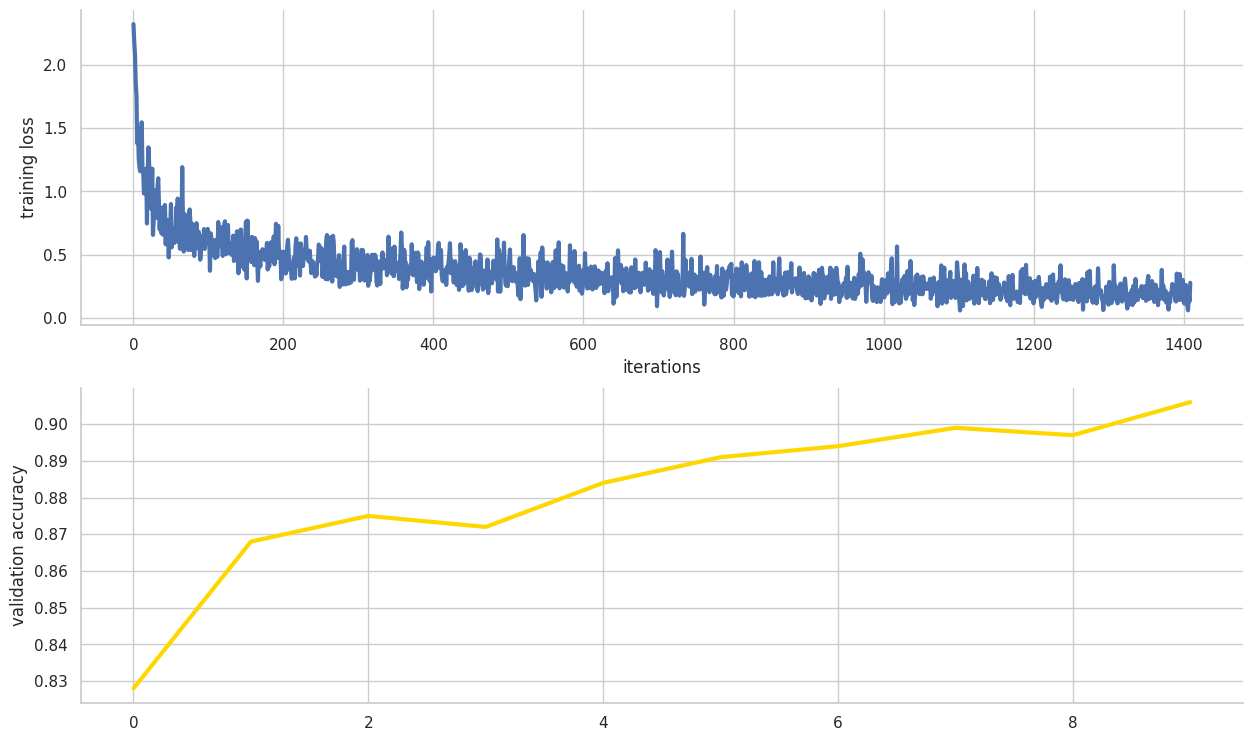

In [15]:
# Visualize training loss

# Plot training loss and validation accuracy
plt.figure(figsize = (15, 9))

# Plot training loss over iterations
plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("iterations")
sns.despine()


# Plot validation accuracy over epochs
plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")
sns.despine()

In [16]:
# Compute the testing accuracy

# Set model to evaluation mode
model.eval()


# Turn off gradients since we are only evaluating
with torch.no_grad():
    # Get model predictions on test data
    outputs = model(test_features_tensor)

    # Take the class with the highest score
    _, predicted = torch.max(outputs, 1)

    # Compare predictions to true labels and compute accuracy
    test_accuracy = (predicted == test_targets_tensor).float().mean().item()
# Print
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9010000228881836


In [17]:
# (OPTIONAL) Print the testing accuracy for each fashion class. Your code should produce something that looks like:
# Clever usage of np.where() could be useful here

# "Accuracy of T-shirt/top: 93.5 %"
# "Accuracy of Trouser: 89.3 %"
# etc...

# What's the fashion item that your model had the hardest time classifying?

# YOUR CODE HERE